# ML surrogates of the digital twin with conformal prediction intervals

Train: open-loop LHS (2000, seed 0). Test: Saltelli set (4096), a different sampling scheme, for honest generalisation;
5-fold CV inside the training set. Inputs standardised. Models per target: HistGradientBoosting, Gaussian process
(Matern 5/2 + white noise, 1000-point subset), MLP (2 x 64 tanh). Physics-informed features: equilibrium CH4
conversion at the base outlet temperature and the specific duty Q_comb/feed. Uncertainty: MAPIE CV+ (5 folds) on the
best model per target, GP native intervals for comparison. Training was run by `rdt.surrogate.train_all`; models are in
`models/` (git-ignored), metrics in `data/design/surrogate_metrics_v1.json`. This notebook loads them and draws the
parity figure. Life targets rest on the Yeh Manaurite XM placeholder Larson-Miller curve.

In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from rdt import surrogate as s

pd.set_option("display.width", 250)
if not s.METRICS_JSON.exists():
    print("metrics missing: training now (about 9 minutes)")
    import subprocess, sys
    out = s.train_all(); M = out["metrics"]; tr, te = out["train"], out["test"]
    M["conformal"] = {t: {k: v for k, v in s.conformalize(t, M["targets"][t]["best"], tr, te).items() if not k.startswith("_")} for t in s.TARGETS}
    json.dump(M, open(s.METRICS_JSON, "w"), indent=2)
M = json.loads(s.METRICS_JSON.read_text())
print(f"train {M['n_train']} (LHS) / test {M['n_test']} (Saltelli); GP subset {M['gp_subset']}; total pipeline time {M.get('total_wall_time_s', float('nan')):.0f} s")
rows = []
for tgt, rt in M["targets"].items():
    for key, m in rt["models"].items():
        rows.append({"target": tgt, "model": key, "R2_test": m["test"]["r2"], "RMSE_test": m["test"]["rmse"], "max|err|_test": m["test"]["max_abs_error"],
                     "RMSE_cv5": m["cv5"]["rmse"], "pred_s_per_1e5": m["predict_time_per_1e5_s"], "best": key == rt["best"]})
tab = pd.DataFrame(rows)
print(tab.to_string(index=False, float_format=lambda v: f"{v:.4g}"))
print("\nphysics-feature effect on test RMSE (% change, negative = better):")
print(pd.DataFrame({t: rt["physics_feature_rmse_change_pct"] for t, rt in M["targets"].items()}).T.round(1).to_string())


train 2000 (LHS) / test 4096 (Saltelli); GP subset 1000; total pipeline time 530 s
          target        model  R2_test  RMSE_test  max|err|_test  RMSE_cv5  pred_s_per_1e5  best
      T_wo_max_K    hgb__base   0.9838      3.081          14.17     3.404          0.6286 False
      T_wo_max_K     gp__base        1    0.03054          1.276   0.02276           3.779 False
      T_wo_max_K    mlp__base   0.9996     0.5063          4.071    0.5172         0.06667 False
      T_wo_max_K hgb__physics   0.9868      2.783          14.93     3.073            0.68 False
      T_wo_max_K  gp__physics        1    0.02998          1.262   0.02044           3.845  True
      T_wo_max_K mlp__physics   0.9994     0.5816          4.499    0.5745         0.08989 False
 z_frac_T_wo_max    hgb__base  0.07352     0.0226         0.6017   0.01639          0.7564 False
 z_frac_T_wo_max     gp__base   0.1243    0.02198         0.5783  0.001463           2.503 False
 z_frac_T_wo_max    mlp__base   0.1374    0.

In [2]:
cov = []
for tgt, c in M["conformal"].items():
    r = {"target": tgt, "best_model": c["model"], "method": "CV+"}
    for cl in ("0.9", "0.95"):
        r[f"PICP_{cl}"] = c["levels"][cl]["picp"]; r[f"MPIW_{cl}"] = c["levels"][cl]["mpiw"]
    cov.append(r)
for tgt, g in M.get("gp_native_intervals", {}).items():
    r = {"target": tgt, "best_model": f"gp__{g['features']}", "method": "GP native"}
    for cl in ("0.9", "0.95"):
        r[f"PICP_{cl}"] = g["levels"][cl]["picp"]; r[f"MPIW_{cl}"] = g["levels"][cl]["mpiw"]
    cov.append(r)
for tgt, g in M.get("conformal_cv_base_comparison", {}).items():
    if not isinstance(g, dict) or "levels" not in g: continue
    r = {"target": tgt, "best_model": M["targets"][tgt]["best"], "method": "CV (base)"}
    for cl in ("0.9", "0.95"):
        r[f"PICP_{cl}"] = g["levels"][cl]["picp"]; r[f"MPIW_{cl}"] = g["levels"][cl]["mpiw"]
    cov.append(r)
print(pd.DataFrame(cov).to_string(index=False, float_format=lambda v: f"{v:.4g}"))
print("\n" + M.get("coverage_note", ""))
sp = M["speed"]; print(f"\nspeed: physics {sp['physics_model_s_per_run']:.3f} s/run, best T_wo surrogate {1e6*sp['best_T_wo_surrogate_s_per_run']:.1f} us/run -> speed-up {sp['speedup_factor']:.3g}x; base case T_wo_max physics {sp['physics_base_case_T_wo_max_K']:.2f} K vs surrogate {sp['surrogate_base_case_T_wo_max_K']:.2f} K")


          target   best_model    method  PICP_0.9  MPIW_0.9  PICP_0.95  MPIW_0.95
      T_wo_max_K  gp__physics       CV+    0.9395   0.06217     0.9668    0.08568
 z_frac_T_wo_max mlp__physics       CV+    0.9749    0.0106     0.9944    0.01338
         T_out_K  gp__physics       CV+    0.9426   0.05794     0.9739    0.08878
       P_out_bar     gp__base       CV+    0.9585 0.0009932     0.9829   0.001523
CH4_slip_dry_pct  gp__physics       CV+    0.9497  0.003705     0.9785   0.005283
   H2_net_kmol_h  gp__physics       CV+    0.9431  0.002479     0.9773    0.00375
          duty_W     gp__base       CV+    0.9451 1.104e+04     0.9746  1.617e+04
   log10_t_r_hot     gp__base       CV+    0.9353  0.002332     0.9719   0.003078
      T_wo_max_K  gp__physics GP native    0.9807    0.0739      0.991    0.08805
CH4_slip_dry_pct  gp__physics GP native    0.9858  0.004679     0.9907   0.005575
   log10_t_r_hot     gp__base GP native    0.9609  0.002545       0.98   0.003032
      T_wo_max_K

saved /Users/izbassar/Documents/Projects/reformer-digital-twin/paper/figures/fig09_surrogate_parity.png


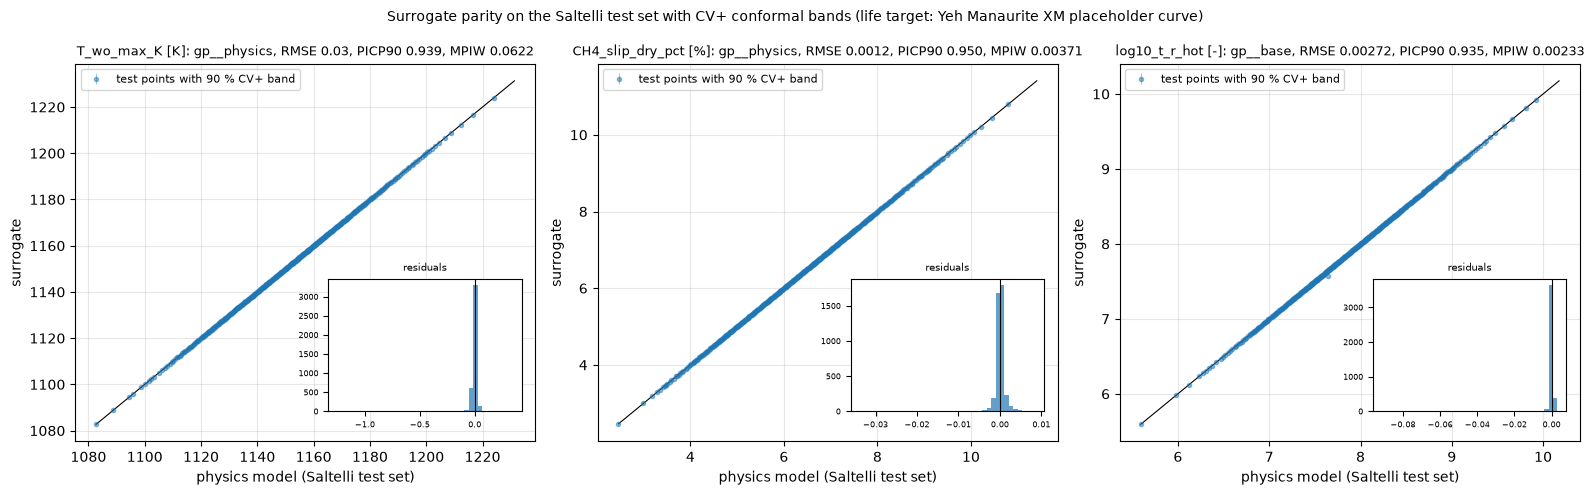

In [3]:
tr, te = s.load_data(); te = s.add_physics_features(te)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (tgt, unit) in zip(axes, (("T_wo_max_K", "K"), ("CH4_slip_dry_pct", "%"), ("log10_t_r_hot", "-"))):
    b = joblib.load(s.MODELS_DIR / f"{tgt}__conformal.joblib"); cc = b["conformal"]; feats = b["features"]
    X = te[feats].to_numpy(float); y = te[tgt].to_numpy(float)
    yp, iv = cc.predict_interval(X)
    lo, hi = iv[:, 0, 0], iv[:, 1, 0]
    order = np.argsort(y); n = len(y); sub = order[:: max(1, n // 400)]
    ax.errorbar(y[sub], yp[sub], yerr=[yp[sub] - lo[sub], hi[sub] - yp[sub]], fmt="o", ms=3, alpha=0.5, ecolor="C0", elinewidth=0.6, label="test points with 90 % CV+ band")
    lim = [y.min(), y.max()]; ax.plot(lim, lim, "k-", lw=0.8)
    rm = M["targets"][tgt]["models"][M["targets"][tgt]["best"]]["test"]["rmse"]; pc = M["conformal"][tgt]["levels"]["0.9"]
    ax.set_title(f"{tgt} [{unit}]: {M['targets'][tgt]['best']}, RMSE {rm:.3g}, PICP90 {pc['picp']:.3f}, MPIW {pc['mpiw']:.3g}", fontsize=9)
    ax.set_xlabel("physics model (Saltelli test set)"); ax.set_ylabel("surrogate"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
    ins = ax.inset_axes([0.55, 0.08, 0.42, 0.35]); res = yp - y
    ins.hist(res, bins=40, color="C0", alpha=0.7); ins.axvline(0, color="k", lw=0.8); ins.set_title("residuals", fontsize=7); ins.tick_params(labelsize=6)
fig.suptitle("Surrogate parity on the Saltelli test set with CV+ conformal bands (life target: Yeh Manaurite XM placeholder curve)", fontsize=10)
fig.tight_layout(); out = Path("..") / "paper" / "figures" / "fig09_surrogate_parity.png"; fig.savefig(out, dpi=150); print("saved", out.resolve()); plt.show()
